# `flavor_tagging` — b-jet tagging from tracks and clusters

A first, from-scratch flavor-tagging exercise: simulate a mix of light jets
and b-jets with `detectorsim2d`'s `jets` gun mode, smear them into tracks
and clusters with `detectorreco2d` (see `12_detectorreco2d_reconstruction`),
check the reconstructed pipeline against the observables a real tagger
would build on, then train one -- a small MLP that scores a jet as light or
b-flavored from those observables alone, evaluated on an *independently*
simulated run.

A **b-jet** here stands in for a jet containing a B hadron: instead of
every particle starting at the primary vertex, the whole jet's particles
share one vertex displaced 10-90 units along the jet axis (an invisible
flight before the B hadron decays), plus three opt-in knobs on top of that
displacement (`configs/jets_bjets.yaml`):

- **~20% more tracks** than an equivalent light jet (`b_jet_track_boost`)
- **~15% higher pt** (`b_jet_pt_boost`)
- **a muon far more often**: 15% of b-jets vs. 2% of light jets
  (`b_jet_muon_fraction`/`jet_muon_fraction`) -- standing in for a
  semileptonic B decay, historically one of the most powerful single
  b-tagging handles (soft-lepton tagging)

The displaced vertex alone already widens a b-jet track's impact-parameter
(`d0`) distribution relative to a light jet's (whose trajectories genuinely
pass through the origin) -- see `detector2d.geometry.Trajectory.d0`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

from flavor_tagging.pipeline import run_pipeline, summarize_jets
from flavor_tagging.vis import plot_track_d0, plot_cluster_energy, plot_track_multiplicity, plot_muon_multiplicity
from flavor_tagging.dataset import build_dataset
from flavor_tagging.train import train_model, save_checkpoint, load_checkpoint
from flavor_tagging.evaluate import evaluate_model, plot_roc, plot_confusion_matrix, plot_score_distribution

## Two independent runs: train and test

`run_pipeline` simulates *and* reconstructs one run in a single call, from
`configs/jets_bjets.yaml`/`configs/reco.yaml` by default. Training and
evaluation each need their **own** run -- different seeds, so evaluation
measures generalization to new random draws rather than replaying the
training set.

In [2]:
_particles, _hits, _deposits, train_tracks, train_clusters = run_pipeline(seed=42)
_particles, _hits, _deposits, test_tracks, test_clusters = run_pipeline(seed=4242)

train_jets = summarize_jets(train_tracks)
test_jets = summarize_jets(test_tracks)
print(f"train: {len(train_jets)} jets, {int(train_jets['is_b_jet'].sum())} b-jets")
print(f"test:  {len(test_jets)} jets, {int(test_jets['is_b_jet'].sum())} b-jets")

train: 895 jets, 142 b-jets
test:  883 jets, 139 b-jets


## Validation plots: does the pipeline reproduce its own knobs?

Each plot compares light jets against b-jets using the truth `is_b_jet`
label carried end to end from the gun (`detectorsim2d.edm.PARTICLES_COLUMNS`)
through reconstruction (`detectorreco2d.edm`) -- these check that the
pipeline reproduces its own configured knobs, not a trained tagger's
output. That's next.

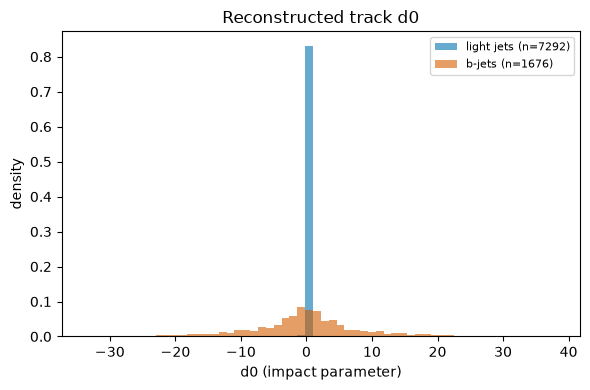

In [3]:
fig = plot_track_d0(train_tracks)

The b-jet distribution is visibly wider -- the displaced-vertex effect.

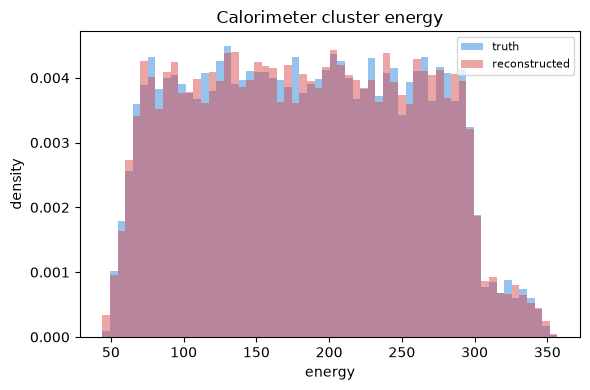

In [4]:
fig = plot_cluster_energy(train_clusters)

Truth vs. reconstructed cluster energy, overlaid -- the resolution smearing itself, independent of jet flavor.

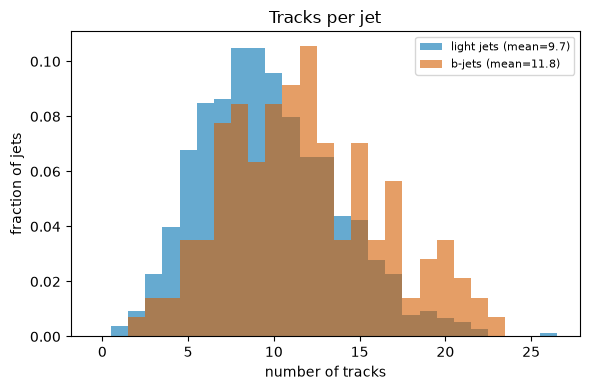

In [5]:
fig = plot_track_multiplicity(train_tracks)

The `b_jet_track_boost` effect: b-jets average visibly more reconstructed tracks.

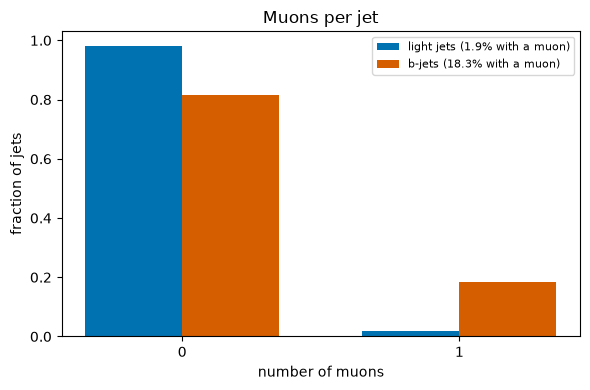

In [6]:
fig = plot_muon_multiplicity(train_tracks)

The `jet_muon_fraction`/`b_jet_muon_fraction` split: a b-jet contains a muon far more often than a light jet.

## Event display: a light jet vs. a b-jet

The plots above show *distributions* over many jets; one actual event
makes the underlying picture concrete. `detectorsim2d.vis.plot_event`
draws a full event's geometry -- detector layers, one colored trajectory
per particle, hits, calorimeter deposits -- so pre-filtering its
`particles` argument down to a single `(event_id, jet_id)` isolates just
that jet's tracks, the same trick `03_detectorsim2d_event_simulation` uses
to spot a b-jet's displaced vertex in a full `jets`-mode event.

This uses its own dedicated simulation run (`simulate_jets`, truth-level
only -- no reconstruction needed to just look at trajectories) rather than
`train_tracks`/`train_clusters`, since those keep `particles` around only
as the throwaway `_particles`.

In [7]:
import numpy as np

from flavor_tagging.pipeline import simulate_jets, SIM_CONFIG_PATH
from detectorsim2d.config import load_config as load_sim_config
from detectorsim2d.vis import plot_event
from viz_style import PRESENT, use_theme

display_config = load_sim_config(SIM_CONFIG_PATH)
display_particles, display_hits, display_deposits = simulate_jets(display_config, rng=np.random.default_rng(7))

jetted = display_particles[display_particles["jet_id"] != -1]
jets = jetted.groupby(["event_id", "jet_id"], as_index=False).agg(
    is_b_jet=("is_b_jet", "first"), n_particles=("particle_id", "count"), x0=("x0", "first"), y0=("y0", "first"),
)
jets["r0"] = np.hypot(jets["x0"], jets["y0"])

# the b-jet with the largest, most unambiguous vertex displacement...
b_jet_row = jets[jets["is_b_jet"]].sort_values("r0", ascending=False).iloc[0]
# ...and a light jet with a matching track count, for a fair side-by-side
light_jet_row = jets[~jets["is_b_jet"] & (jets["n_particles"] == b_jet_row["n_particles"])].iloc[0]

print(f"light jet: event {light_jet_row.event_id}, jet {light_jet_row.jet_id}, "
      f"{light_jet_row.n_particles} particles, vertex at r={light_jet_row.r0:.1f}")
print(f"b-jet:     event {b_jet_row.event_id}, jet {b_jet_row.jet_id}, "
      f"{b_jet_row.n_particles} particles, vertex at r={b_jet_row.r0:.1f}")

light jet: event 1, jet 0, 23 particles, vertex at r=0.0
b-jet:     event 75, jet 3, 23 particles, vertex at r=89.9


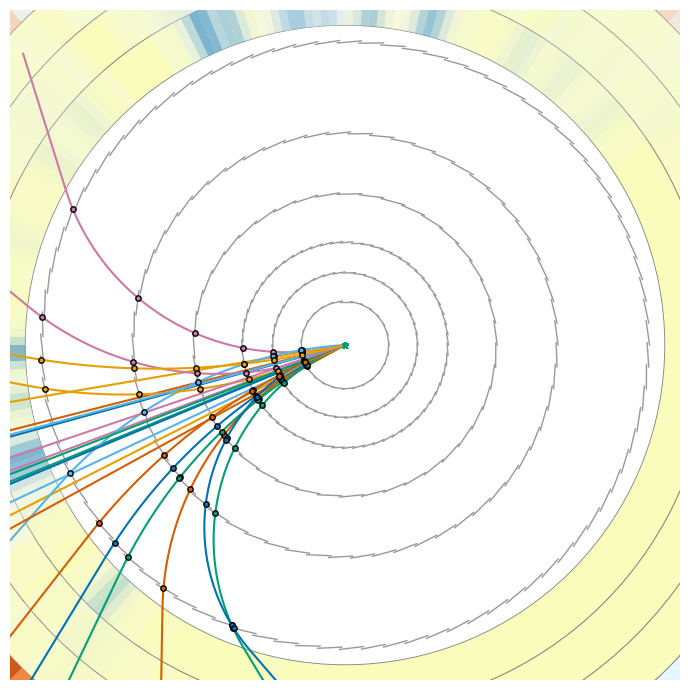

In [8]:
def plot_jet(event_id, jet_id):
    """One jet's tracks, isolated by pre-filtering `particles` to a single
    `(event_id, jet_id)` before handing it to `plot_event` -- `hits`/
    `deposits` stay unfiltered, but `plot_event` only ever draws the ones
    belonging to the particles it's given, so the rest of the event is
    simply never touched."""
    jet_particles = display_particles[
        (display_particles["event_id"] == event_id) & (display_particles["jet_id"] == jet_id)
    ]
    with use_theme(PRESENT):
        fig = plot_event(
            jet_particles, display_hits, display_config.layers, event_id=event_id,
            deposits=display_deposits, field=display_config.field_regions,
            world_radius=display_config.world_radius, max_path_length=display_config.max_path_length,
        )
    # zoom into the tracker -- at the full detector's scale (world_radius=800)
    # a <=90-unit vertex displacement is imperceptible
    fig.axes[0].set_xlim(-220, 220)
    fig.axes[0].set_ylim(-220, 220)
    return fig


fig = plot_jet(light_jet_row.event_id, light_jet_row.jet_id)

The light jet's vertex star sits exactly on the tracker's common center --
every track curves back to `(x0, y0) = (0, 0)`, the primary vertex.

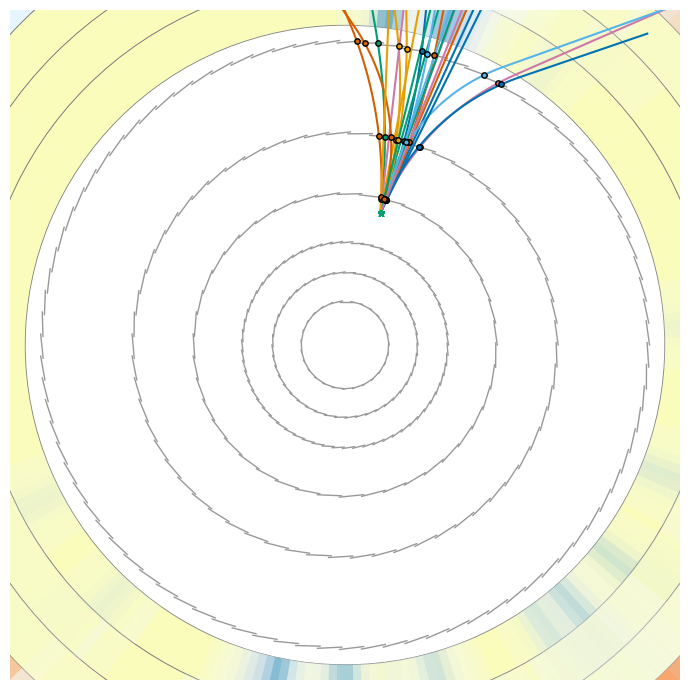

In [9]:
fig = plot_jet(b_jet_row.event_id, b_jet_row.jet_id)

The b-jet's vertex star sits well outside the origin, near the second
tracker layer -- the flight the invisible B hadron took (up to
`b_jet_decay_length_max = 90` in `configs/jets_bjets.yaml`) before decaying
into this jet's visible particles. Every track curves back to that
off-center point instead of `(0, 0)`.

## Building the b-tagger's dataset

`build_dataset` turns one reconstructed run's `tracks`/`clusters` into one
example per truth jet, with a **fixed-size** feature vector regardless of
that jet's own track count: an overcommitted, zero-padded array of leading
-track `d0` (sorted by descending reconstructed `pt`, sized to the busiest
jet in the training set -- `compute_n_track_slots`), plus four scalars:
`n_tracks`, `n_muons`, `total_cluster_energy`, `n_clusters`. Features are
standardized (fit on the training set only) before going into the MLP.

In [10]:
train_dataset = build_dataset(train_tracks, train_clusters)
n_scalars = len(train_dataset.feature_names) - train_dataset.n_track_slots
print(
    f"{train_dataset.features.shape[0]} examples, {train_dataset.features.shape[1]} features "
    f"({train_dataset.n_track_slots} d0 slots + {n_scalars} scalars)"
)
train_dataset.feature_names

895 examples, 30 features (26 d0 slots + 4 scalars)


['d0_track_0',
 'd0_track_1',
 'd0_track_2',
 'd0_track_3',
 'd0_track_4',
 'd0_track_5',
 'd0_track_6',
 'd0_track_7',
 'd0_track_8',
 'd0_track_9',
 'd0_track_10',
 'd0_track_11',
 'd0_track_12',
 'd0_track_13',
 'd0_track_14',
 'd0_track_15',
 'd0_track_16',
 'd0_track_17',
 'd0_track_18',
 'd0_track_19',
 'd0_track_20',
 'd0_track_21',
 'd0_track_22',
 'd0_track_23',
 'd0_track_24',
 'd0_track_25',
 'n_tracks',
 'n_muons',
 'total_cluster_energy',
 'n_clusters']

## Training

`train_model` derives and returns the standardization (`mean`/`std`) and
`n_track_slots` alongside the trained model, bundled together as
`preprocessing` -- both must be reused for any later dataset (an
independent evaluation set embedded/scaled any other way would not be
comparable), which `evaluate_model` below does automatically given a
checkpoint's `preprocessing` dict.

epoch   1/50  train_loss=0.7199  val_loss=0.6991  val_acc=0.281
epoch   2/50  train_loss=0.6840  val_loss=0.6640  val_acc=0.933
epoch   3/50  train_loss=0.6488  val_loss=0.6264  val_acc=0.933
epoch   4/50  train_loss=0.6093  val_loss=0.5821  val_acc=0.933
epoch   5/50  train_loss=0.5614  val_loss=0.5294  val_acc=0.926
epoch   6/50  train_loss=0.5033  val_loss=0.4692  val_acc=0.933
epoch   7/50  train_loss=0.4389  val_loss=0.4053  val_acc=0.919
epoch   8/50  train_loss=0.3717  val_loss=0.3419  val_acc=0.911
epoch   9/50  train_loss=0.3069  val_loss=0.2843  val_acc=0.911
epoch  10/50  train_loss=0.2492  val_loss=0.2370  val_acc=0.911
epoch  11/50  train_loss=0.2017  val_loss=0.1997  val_acc=0.926
epoch  12/50  train_loss=0.1668  val_loss=0.1694  val_acc=0.941
epoch  13/50  train_loss=0.1389  val_loss=0.1458  val_acc=0.956
epoch  14/50  train_loss=0.1191  val_loss=0.1269  val_acc=0.956
epoch  15/50  train_loss=0.1029  val_loss=0.1109  val_acc=0.963


epoch  16/50  train_loss=0.0902  val_loss=0.0975  val_acc=0.963
epoch  17/50  train_loss=0.0796  val_loss=0.0865  val_acc=0.963
epoch  18/50  train_loss=0.0712  val_loss=0.0764  val_acc=0.970
epoch  19/50  train_loss=0.0635  val_loss=0.0690  val_acc=0.970
epoch  20/50  train_loss=0.0579  val_loss=0.0610  val_acc=0.970
epoch  21/50  train_loss=0.0521  val_loss=0.0549  val_acc=0.978
epoch  22/50  train_loss=0.0475  val_loss=0.0502  val_acc=0.978
epoch  23/50  train_loss=0.0434  val_loss=0.0447  val_acc=0.993
epoch  24/50  train_loss=0.0400  val_loss=0.0409  val_acc=0.993
epoch  25/50  train_loss=0.0373  val_loss=0.0374  val_acc=0.993
epoch  26/50  train_loss=0.0345  val_loss=0.0347  val_acc=0.993
epoch  27/50  train_loss=0.0320  val_loss=0.0320  val_acc=0.993
epoch  28/50  train_loss=0.0296  val_loss=0.0295  val_acc=0.993
epoch  29/50  train_loss=0.0275  val_loss=0.0274  val_acc=0.993
epoch  30/50  train_loss=0.0255  val_loss=0.0260  val_acc=0.993
epoch  31/50  train_loss=0.0238  val_los

epoch  32/50  train_loss=0.0223  val_loss=0.0240  val_acc=0.993
epoch  33/50  train_loss=0.0212  val_loss=0.0225  val_acc=0.993
epoch  34/50  train_loss=0.0194  val_loss=0.0218  val_acc=0.993
epoch  35/50  train_loss=0.0183  val_loss=0.0209  val_acc=0.993
epoch  36/50  train_loss=0.0170  val_loss=0.0205  val_acc=0.993
epoch  37/50  train_loss=0.0160  val_loss=0.0198  val_acc=0.993
epoch  38/50  train_loss=0.0151  val_loss=0.0199  val_acc=0.993
epoch  39/50  train_loss=0.0142  val_loss=0.0194  val_acc=0.993
epoch  40/50  train_loss=0.0134  val_loss=0.0193  val_acc=0.993
epoch  41/50  train_loss=0.0126  val_loss=0.0191  val_acc=0.993
epoch  42/50  train_loss=0.0119  val_loss=0.0188  val_acc=0.993
epoch  43/50  train_loss=0.0114  val_loss=0.0192  val_acc=0.993
epoch  44/50  train_loss=0.0106  val_loss=0.0193  val_acc=0.993
epoch  45/50  train_loss=0.0100  val_loss=0.0187  val_acc=0.993
epoch  46/50  train_loss=0.0098  val_loss=0.0189  val_acc=0.993


epoch  47/50  train_loss=0.0095  val_loss=0.0184  val_acc=0.993
epoch  48/50  train_loss=0.0093  val_loss=0.0196  val_acc=0.993
epoch  49/50  train_loss=0.0083  val_loss=0.0190  val_acc=0.993
epoch  50/50  train_loss=0.0077  val_loss=0.0193  val_acc=0.993


Text(0.5, 1.0, 'final val accuracy: 99.3%')

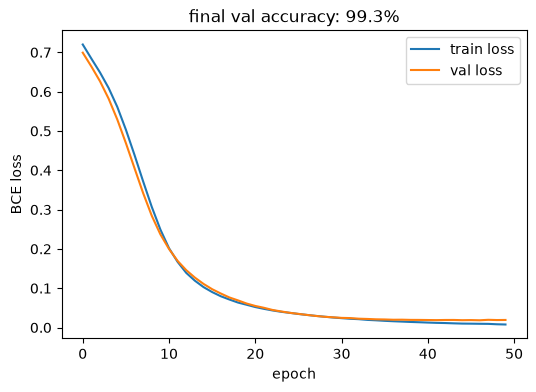

In [11]:
model, preprocessing, history = train_model(train_tracks, train_clusters, epochs=50, seed=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.train_loss, label="train loss")
ax.plot(history.val_loss, label="val loss")
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.legend()
ax.set_title(f"final val accuracy: {history.val_accuracy[-1]:.1%}")

## Evaluating on the independent test run

A checkpoint round-trip (`save_checkpoint`/`load_checkpoint`) bundles the
model with the `preprocessing` it was trained with -- exactly what
`evaluate_model` needs to embed `test_tracks`/`test_clusters` identically
to how training embedded its own data, even though this test run's busiest
jet may have a different track count than the training run's.

In [12]:
import os
import tempfile

ckpt_path = os.path.join(tempfile.mkdtemp(), "btagger.pt")
save_checkpoint(ckpt_path, model, preprocessing)
model, preprocessing = load_checkpoint(ckpt_path)

result = evaluate_model(model, preprocessing, test_tracks, test_clusters)
print(f"accuracy: {result['accuracy']:.1%}")
print(f"AUC:      {result['roc_auc']:.3f}")
print("confusion matrix (rows=true [light, b-jet], cols=predicted):")
print(result["confusion_matrix"])

accuracy: 97.4%
AUC:      0.966
confusion matrix (rows=true [light, b-jet], cols=predicted):
[[744   0]
 [ 23 116]]


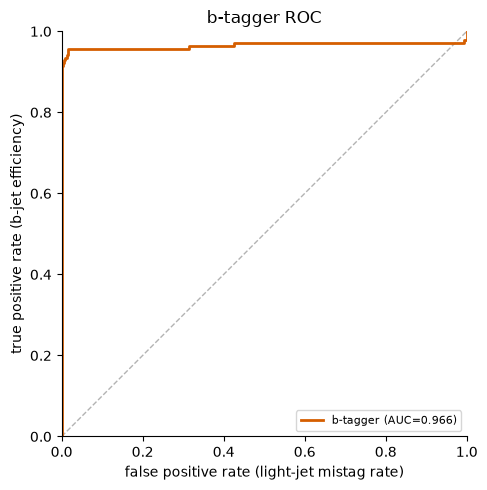

In [13]:
fig = plot_roc(result["fpr"], result["tpr"], result["roc_auc"])

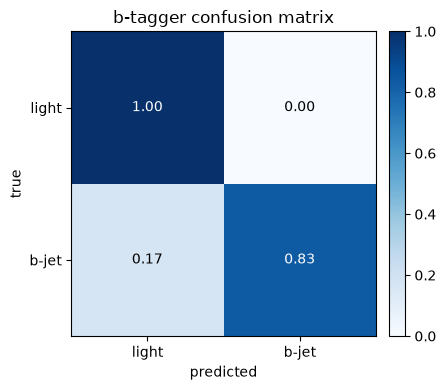

In [14]:
fig = plot_confusion_matrix(result["confusion_matrix"])

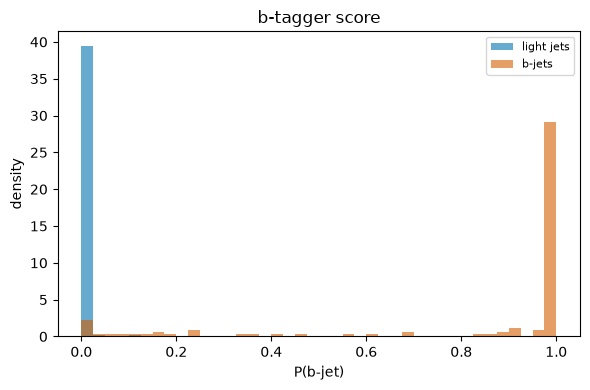

In [15]:
fig = plot_score_distribution(result["score"], result["dataset"].is_b_jet)

## Reading the score distribution

Accuracy and AUC compress the result to single numbers; the score
distribution above shows the actual separation: light jets pile up at 0
and most b-jets at 1, but a genuine minority of b-jets score low -- the
ones without a wide `d0`, extra tracks, or a muon to give them away. Those
are honestly hard to distinguish from a light jet on these features alone,
which is exactly what a non-degenerate classifier should look like.